# 02 Exploratory Data Analysis
Understand distributions, correlations and outliers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load full dataset — all columns kept intentionally.
# Feature selection happens in notebook 03, not here.
df = pd.read_csv('../data/processed/listings_raw.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (6718, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,snapshot_month
0,73282.0,https://www.airbnb.com/rooms/73282,2.025060e+13,27.06.2025,previous scrape,"Clean, central, quiet",Arty neighborhood,NaN,https://a0.muscache.com/pictures/481072/abd94c...,377532,...,4.71,4.61,NaN,f,1,1,0,0,0.29,2025-06
1,143821.0,https://www.airbnb.com/rooms/143821,2.025060e+13,27.06.2025,city scrape,LOFT on 2 floors in Sihlcity Zürich,EXPERIENCE AN UNUSAL STAY IN THE MIDDLE OF ZUR...,NaN,https://a0.muscache.com/pictures/1012249/a4f34...,697307,...,NaN,NaN,NaN,f,1,1,0,0,NaN,2025-06
2,178448.0,https://www.airbnb.com/rooms/178448,2.025060e+13,27.06.2025,city scrape,"a lovely place, top location","Very central location, 5 min walk from Bahnhof...","We live in one of the top locations of Zürich,...",https://a0.muscache.com/pictures/7d41e016-e818...,854016,...,5.00,4.89,NaN,f,1,0,1,0,0.05,2025-06
3,227039.0,https://www.airbnb.com/rooms/227039,2.025060e+13,27.06.2025,city scrape,*Luxury Penthouse in the heart of trendy Zurich*,Modern and unique penthouse apartment over thr...,Zurich is hip-circuit with the Swiss peacefuln...,https://a0.muscache.com/pictures/c93b46a3-ceb0...,1184427,...,4.94,4.84,NaN,f,1,1,0,0,0.19,2025-06
4,283737.0,https://www.airbnb.com/rooms/283737,2.025060e+13,27.06.2025,city scrape,Best Location in Zurich Oldtown,"The confortable, clean and authentic flat is i...",In my opinion the niederdorf is the most beaut...,https://a0.muscache.com/pictures/b0b6eedd-d96c...,1477771,...,4.93,4.41,NaN,f,3,3,0,0,2.29,2025-06


In [2]:
# Clean price for EDA plots only — original df keeps all columns
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df = df[df['price'] > 0].dropna(subset=['price'])
print(f'After price filter: {df.shape}')
print(df['price'].describe())

After price filter: (5095, 80)
count     5095.000000
mean       189.430029
std        360.805924
min         10.000000
25%        100.000000
50%        139.000000
75%        205.000000
max      10000.000000
Name: price, dtype: float64


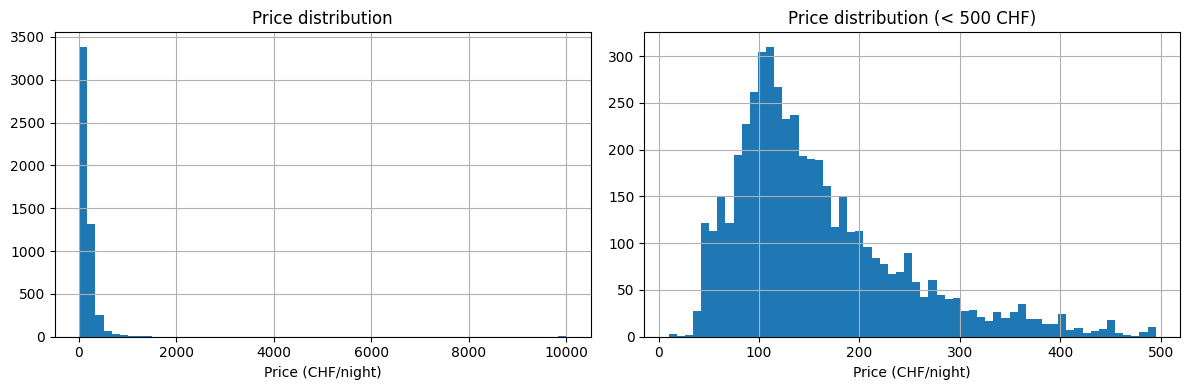

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price'].hist(bins=60, ax=axes[0])
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price (CHF/night)')

df[df['price'] < 500]['price'].hist(bins=60, ax=axes[1])
axes[1].set_title('Price distribution (< 500 CHF)')
axes[1].set_xlabel('Price (CHF/night)')
plt.tight_layout()
plt.savefig('../reports/figures/price_distribution.png', dpi=150)
plt.show()

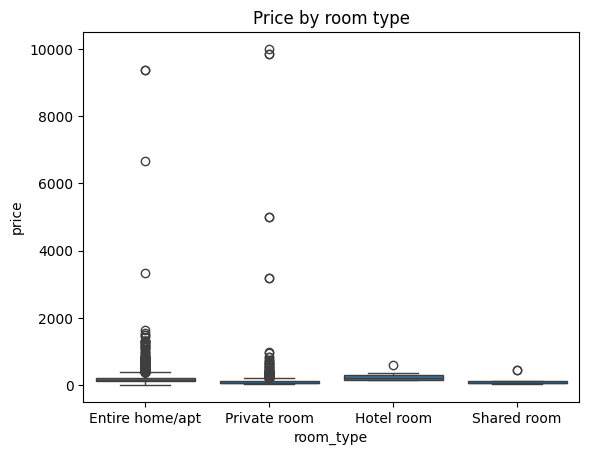

In [4]:
sns.boxplot(data=df, x='room_type', y='price')
plt.title('Price by room type')
plt.savefig('../reports/figures/price_by_room_type.png', dpi=150)
plt.show()

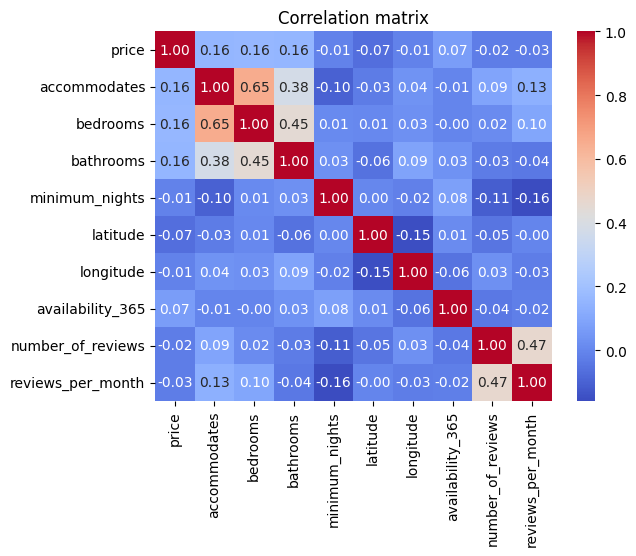

In [5]:
numeric = df[['price','accommodates','bedrooms','bathrooms','minimum_nights',
              'latitude','longitude','availability_365','number_of_reviews','reviews_per_month']]
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150)
plt.show()

In [6]:
df.to_csv('../data/processed/listings_eda.csv', index=False)
print('EDA dataset saved.')

EDA dataset saved.
